# **FYP Data Cleaning**

**Import Module**

All the import module will be written below

In [188]:
import pandas as pd
from tabulate import tabulate
from scipy.stats import skew, kurtosis
import numpy as np
import holidays
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose

**Function for Statistical Analysis (Class Variable)**

In [189]:
def categorical_summary(df):
    summary = []

    for col in df.select_dtypes(include='object').columns:
        value_counts = df[col].value_counts(dropna=False)
        n_missing = df[col].isnull().sum()
        n_levels = df[col].nunique(dropna=True)

        mode1 = value_counts.index[0]
        mode1_pct = round(100 * value_counts.iloc[0] / len(df), 2)

        if len(value_counts) > 1:
            mode2 = value_counts.index[1]
            mode2_pct = round(100 * value_counts.iloc[1] / len(df), 2)
        else:
            mode2 = None
            mode2_pct = None

        summary.append({
            'Variable Name': col,
            'Levels': n_levels,
            'Missing': n_missing,
            'Mode': mode1,
            'Mode %': mode1_pct,
            'Mode2': mode2,
            'Mode2 %': mode2_pct
        })

    return pd.DataFrame(summary)

**Function for Statistical Analysis (Interval Variable)**

In [190]:
def interval_summary(df):
    summary = []

    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        data = df[col].dropna()
        n_missing = df[col].isnull().sum()

        summary.append({
            'Variable': col,
            'Mean': round(data.mean(), 4),
            'Std Dev': round(data.std(), 4),
            'Missing': n_missing,
            'Min': data.min(),
            'Median': data.median(),
            'Max': data.max(),
            'Skewness': round(skew(data), 4),
            'Kurtosis': round(kurtosis(data), 4)
        })

    return pd.DataFrame(summary)

**Function for Statistical Analysis (DateTime Variable)**

In [191]:
def datetime_summary(df):
    summary = []

    for col in df.select_dtypes(include='datetime').columns:
        n_missing = df[col].isnull().sum()
        min_date = df[col].min()
        max_date = df[col].max()

        summary.append({
            'Variable Name': col,
            'Type': 'datetime',
            'Missing': n_missing,
            'Earliest': min_date,
            'Latest': max_date,
        })

    return pd.DataFrame(summary)

**olist_products_dataset.csv**

Read olist_products_dataset.csv

In [192]:
product_df = pd.read_csv("data/olist_products_dataset.csv")
product_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


Replace empty row

In [193]:
#separating the missing values and known values
missing=product_df[product_df['product_category_name'].isnull()]
all_values= product_df[product_df['product_category_name'].notnull()]

#getting the column names for 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
col=missing.columns[5:]
col

Index(['product_weight_g', 'product_length_cm', 'product_height_cm',
       'product_width_cm'],
      dtype='object')

In [194]:
#checking for match and saving the index and values in a dictionary
match=dict()
for i in missing.index:
    if ((all_values.iloc[:, 5]==missing.loc[i, col[0]]) & (all_values.iloc[:, 6]==missing.loc[i, col[1]]) & (all_values.iloc[:, 7]==missing.loc[i, col[2]]) & (all_values.iloc[:, 8]==missing.loc[i, col[3]])).sum()>0:
        #saving the product category which is most occuring
        match[i]=all_values[(all_values.iloc[:, 5]==missing.loc[i, col[0]]) & (all_values.iloc[:, 6]==missing.loc[i, col[1]]) & (all_values.iloc[:, 7]==missing.loc[i, col[2]]) & (all_values.iloc[:, 8]==missing.loc[i, col[3]])]['product_category_name'].value_counts().head(1).index
    else:
        match[i]='empty'

In [195]:
#imputing the missing values
for i in match.keys():
    if match[i]!='empty':
        #where there is a match we are filling the value with median of columns for the category we are assigning
        product_df.loc[i, 'product_category_name']=match[i][0]
        product_df.loc[i, 'product_name_lenght']=round(product_df[product_df['product_category_name']== match[i][0]]['product_name_lenght'].median())
        product_df.loc[i, 'product_description_lenght']=round(product_df[product_df['product_category_name']== match[i][0]]['product_description_lenght'].median())
        product_df.loc[i, 'product_photos_qty']=round(product_df[product_df['product_category_name']== match[i][0]]['product_photos_qty'].median())
    else:
        #for no match we are filling with other
        product_df.loc[i, 'product_category_name']='Other'
        product_df.loc[i, 'product_name_lenght']=round(product_df['product_name_lenght'].median())
        product_df.loc[i, 'product_description_lenght']=round(product_df['product_description_lenght'].median())
        product_df.loc[i, 'product_photos_qty']=round(product_df['product_photos_qty'].median())

product_df['product_weight_g']=product_df['product_weight_g'].fillna(round(product_df['product_weight_g'].median()))
product_df['product_length_cm']=product_df['product_length_cm'].fillna(round(product_df['product_length_cm'].median()))
product_df['product_height_cm']=product_df['product_height_cm'].fillna(round(product_df['product_height_cm'].median()))
product_df['product_width_cm']=product_df['product_width_cm'].fillna(round(product_df['product_width_cm'].median()))

Replace product category language

In [196]:
product_translation_df = pd.read_csv("data/product_category_name_translation.csv")
product_translation_df

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [197]:
translation_dict = dict(zip(
    product_translation_df['product_category_name'],
    product_translation_df['product_category_name_english']
))
product_df['product_category_name'] = product_df['product_category_name'].map(translation_dict).fillna(product_df['product_category_name'])
product_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


Statistical Analysis (Class Variable) After Cleaning

In [198]:
cat_summary = categorical_summary(product_df)
print(tabulate(cat_summary, headers='keys', tablefmt='pretty', showindex=False))

+-----------------------+--------+---------+----------------------------------+--------+----------------------------------+---------+
|     Variable Name     | Levels | Missing |               Mode               | Mode % |              Mode2               | Mode2 % |
+-----------------------+--------+---------+----------------------------------+--------+----------------------------------+---------+
|      product_id       | 32951  |    0    | 1e9e8ef04dbcff4541ed26657ea517e5 |  0.0   | d05cc9afc85771f597cf4bc9d8f12546 |   0.0   |
| product_category_name |   74   |    0    |          bed_bath_table          |  9.21  |          sports_leisure          |  8.76   |
+-----------------------+--------+---------+----------------------------------+--------+----------------------------------+---------+


Statistical Analysis (Interval Variable) After Cleaning

In [199]:
int_summary = interval_summary(product_df)
print(tabulate(int_summary, headers='keys', tablefmt='pretty', showindex=False))

+----------------------------+-----------+-----------+---------+-----+--------+---------+----------+----------+
|          Variable          |   Mean    |  Std Dev  | Missing | Min | Median |   Max   | Skewness | Kurtosis |
+----------------------------+-----------+-----------+---------+-----+--------+---------+----------+----------+
|    product_name_lenght     |  48.5117  |  10.1578  |    0    | 5.0 |  51.0  |  76.0   | -0.9197  |  0.256   |
| product_description_lenght | 768.0059  | 629.8397  |    0    | 4.0 | 595.0  | 3992.0  |  1.9903  |  4.9881  |
|     product_photos_qty     |  2.1736   |  1.7266   |    0    | 1.0 |  1.0   |  20.0   |  2.2133  |  7.3926  |
|      product_weight_g      | 2276.3768 | 4281.9264 |    0    | 0.0 | 700.0  | 40425.0 |  3.6048  | 15.1322  |
|     product_length_cm      |  30.8147  |  16.914   |    0    | 7.0 |  25.0  |  105.0  |  1.7505  |  3.5134  |
|     product_height_cm      |  16.9374  |  13.6372  |    0    | 2.0 |  13.0  |  105.0  |  2.1401  |  6.

**olist_orders_dataset.csv**

Read olist_orders_dataset

In [200]:
order_df = pd.read_csv("data/olist_orders_dataset.csv")
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


Replace Data Type

In [201]:
order_df['order_purchase_timestamp'] = pd.to_datetime(order_df['order_purchase_timestamp'])
order_df['order_approved_at'] = pd.to_datetime(order_df['order_approved_at'])
order_df['order_delivered_carrier_date'] = pd.to_datetime(order_df['order_delivered_carrier_date'])
order_df['order_delivered_customer_date'] = pd.to_datetime(order_df['order_delivered_customer_date'])
order_df['order_estimated_delivery_date'] = pd.to_datetime(order_df['order_estimated_delivery_date'])
order_df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Remove Unlogic Row

In [202]:
order_df = order_df[
    ~(
        (order_df['order_status'] == 'delivered') &
        (order_df['order_approved_at'].isna() | (order_df['order_approved_at'].astype(str).str.strip() == ''))
    )
]
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [203]:
order_df = order_df[
    ~(
        (order_df['order_status'] == 'delivered') &
        (order_df['order_delivered_carrier_date'].isna() | (order_df['order_delivered_carrier_date'].astype(str).str.strip() == ''))
    )
]
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [204]:
order_df = order_df[
    ~(
        (order_df['order_status'] == 'delivered') &
        (order_df['order_delivered_customer_date'].isna() | (order_df['order_delivered_customer_date'].astype(str).str.strip() == '')) &
    ~(order_df['order_delivered_carrier_date'].isna() | (order_df['order_delivered_carrier_date'].astype(str).str.strip() == ''))
    )
]
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


**olist_order_items_dataset.csv**

Read olist_order_items_dataset

In [205]:
order_items_df = pd.read_csv("data/olist_order_items_dataset.csv")
order_items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


Replace Data Type

In [206]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])
order_items_df.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

Remove Row with Product ID that not exists

In [207]:
order_items_df = order_items_df[
    order_items_df['product_id'].isin(product_df['product_id'])
]
order_items_df = order_items_df.reset_index(drop=True)
order_items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


Remove Row with Order ID that not exists

In [208]:
order_items_df = order_items_df[
    order_items_df['order_id'].isin(order_df['order_id'])
]
order_items_df = order_items_df.reset_index(drop=True)
order_items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112621,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112622,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112623,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112624,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [209]:
cat_summary = categorical_summary(order_items_df)
print(tabulate(cat_summary, headers='keys', tablefmt='pretty', showindex=False))

+---------------+--------+---------+----------------------------------+--------+----------------------------------+---------+
| Variable Name | Levels | Missing |               Mode               | Mode % |              Mode2               | Mode2 % |
+---------------+--------+---------+----------------------------------+--------+----------------------------------+---------+
|   order_id    | 98643  |    0    | 8272b63d03f5f79c56e9e4120aec44ef |  0.02  | ab14fdcfbe524636d65ee38360e22ce8 |  0.02   |
|  product_id   | 32945  |    0    | aca2eb7d00ea1a7b8ebd4e68314663af |  0.47  | 99a4788cb24856965c36a24e339b6058 |  0.43   |
|   seller_id   |  3095  |    0    | 6560211a19b47992c3666cc44a7e94c0 |  1.81  | 4a3ca9315b744ce9f8e9374361493884 |  1.76   |
+---------------+--------+---------+----------------------------------+--------+----------------------------------+---------+


In [210]:
int_summary = interval_summary(order_items_df)
print(tabulate(int_summary, headers='keys', tablefmt='pretty', showindex=False))

+---------------+----------+----------+---------+------+--------+--------+----------+----------+
|   Variable    |   Mean   | Std Dev  | Missing | Min  | Median |  Max   | Skewness | Kurtosis |
+---------------+----------+----------+---------+------+--------+--------+----------+----------+
| order_item_id |  1.1979  |  0.7052  |    0    | 1.0  |  1.0   |  21.0  |  7.5796  | 103.8344 |
|     price     | 120.6519 | 183.6484 |    0    | 0.85 | 74.99  | 6735.0 |  7.9229  | 120.8104 |
| freight_value | 19.9908  | 15.8078  |    0    | 0.0  | 16.26  | 409.68 |  5.6394  | 59.7764  |
+---------------+----------+----------+---------+------+--------+--------+----------+----------+


In [211]:
date_summary = datetime_summary(order_items_df)
print(tabulate(date_summary, headers='keys', tablefmt='pretty', showindex=False))

+---------------------+----------+---------+---------------------+---------------------+
|    Variable Name    |   Type   | Missing |      Earliest       |       Latest        |
+---------------------+----------+---------+---------------------+---------------------+
| shipping_limit_date | datetime |    0    | 2016-09-19 00:15:34 | 2020-04-09 22:35:08 |
+---------------------+----------+---------+---------------------+---------------------+


Remove Row from order dataset with Order ID that not exists in order item dataset

In [212]:
order_df = order_df[
    order_df['order_id'].isin(order_items_df['order_id'])
]
order_df = order_df.reset_index(drop=True)
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
98638,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
98639,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
98640,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
98641,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [213]:
date_summary = datetime_summary(order_df)
print(tabulate(date_summary, headers='keys', tablefmt='pretty', showindex=False))

+-------------------------------+----------+---------+---------------------+---------------------+
|         Variable Name         |   Type   | Missing |      Earliest       |       Latest        |
+-------------------------------+----------+---------+---------------------+---------------------+
|   order_purchase_timestamp    | datetime |    0    | 2016-09-04 21:15:19 | 2018-09-03 09:06:57 |
|       order_approved_at       | datetime |    0    | 2016-09-15 12:16:38 | 2018-09-03 17:40:06 |
| order_delivered_carrier_date  | datetime |  1007   | 2016-10-08 10:34:01 | 2018-09-11 19:48:28 |
| order_delivered_customer_date | datetime |  2182   | 2016-10-11 13:46:32 | 2018-10-17 13:22:46 |
| order_estimated_delivery_date | datetime |    0    | 2016-10-04 00:00:00 | 2018-10-25 00:00:00 |
+-------------------------------+----------+---------+---------------------+---------------------+


Create quality column for product

In [214]:
quantity_counts = order_items_df['product_id'].value_counts()
product_df['quantity'] = product_df['product_id'].map(quantity_counts).fillna(0).astype(int)
product_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,quantity
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0,1
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,1
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0,1
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0,1
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0,1
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,33
32947,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,2
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,5
32949,83808703fc0706a22e264b9d75f04a2e,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0,7


Save Cleaned Data

In [215]:
product_df.to_csv('Product Data.csv', index=False)
order_df.to_csv('Order Data.csv', index=False)
order_items_df.to_csv('Order Items Data.csv', index=False)

**Sales Forecasting Feature Engineering**

**Preparing Sales Forecasting Dataset (Amount)**

Filter invalid status

In [216]:
sales_forecast_data = order_df[order_df['order_status'] == 'delivered'].drop(['order_status'], axis=1)
sales_forecast_data

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...
98638,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
98639,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
98640,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
98641,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


Data Aggregation

In [217]:
sales_forecast_data = sales_forecast_data.merge(order_items_df, on='order_id')[[
    'order_purchase_timestamp',
    'order_id',
    'price',
    'freight_value',
]]
sales_forecast_data

,order_purchase_timestamp,order_id,price,freight_value
0,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72
1,2018-07-24 20:41:37,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76
2,2018-08-08 08:38:49,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22
3,2017-11-18 19:28:06,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20
4,2018-02-13 21:18:39,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72
...,...,...,...,...
110168,2018-02-06 12:58:58,63943bddc261676b46f01ca7ac2f7bd8,174.90,20.10
110169,2017-08-27 14:46:43,83c1379a015df1e13d02aae0204711ab,205.99,65.02
110170,2018-01-08 21:28:27,11c177c8e97725db2631073c19f07b62,179.99,40.59
110171,2018-01-08 21:28:27,11c177c8e97725db2631073c19f07b62,179.99,40.59


In [218]:
sales_forecast_data['value'] = sales_forecast_data['price'] + sales_forecast_data['freight_value']
sales_forecast_data

,order_purchase_timestamp,order_id,price,freight_value,value
0,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72,38.71
1,2018-07-24 20:41:37,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76,141.46
2,2018-08-08 08:38:49,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22,179.12
3,2017-11-18 19:28:06,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20,72.20
4,2018-02-13 21:18:39,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72,28.62
...,...,...,...,...,...
110168,2018-02-06 12:58:58,63943bddc261676b46f01ca7ac2f7bd8,174.90,20.10,195.00
110169,2017-08-27 14:46:43,83c1379a015df1e13d02aae0204711ab,205.99,65.02,271.01
110170,2018-01-08 21:28:27,11c177c8e97725db2631073c19f07b62,179.99,40.59,220.58
110171,2018-01-08 21:28:27,11c177c8e97725db2631073c19f07b62,179.99,40.59,220.58


In [219]:
sales_forecast_data.drop(['price', 'freight_value'], axis=1, inplace=True)
sales_forecast_data

,order_purchase_timestamp,order_id,value
0,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,38.71
1,2018-07-24 20:41:37,53cdb2fc8bc7dce0b6741e2150273451,141.46
2,2018-08-08 08:38:49,47770eb9100c2d0c44946d9cf07ec65d,179.12
3,2017-11-18 19:28:06,949d5b44dbf5de918fe9c16f97b45f8a,72.20
4,2018-02-13 21:18:39,ad21c59c0840e6cb83a9ceb5573f8159,28.62
...,...,...,...
110168,2018-02-06 12:58:58,63943bddc261676b46f01ca7ac2f7bd8,195.00
110169,2017-08-27 14:46:43,83c1379a015df1e13d02aae0204711ab,271.01
110170,2018-01-08 21:28:27,11c177c8e97725db2631073c19f07b62,220.58
110171,2018-01-08 21:28:27,11c177c8e97725db2631073c19f07b62,220.58


In [220]:
sales_forecast_data = sales_forecast_data[['order_purchase_timestamp', 'value']] 
sales_forecast_data.set_index('order_purchase_timestamp', inplace=True) 

sales_forecast_data.rename({'value': 'sales'}, axis=1, inplace=True) 

sales_forecast_data.sort_index(inplace=True)
sales_forecast_data = sales_forecast_data.resample('D').sum()

sales_forecast_data.dropna(inplace=True)
sales_forecast_data

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13896\1591463190.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_forecast_data.rename({'value': 'sales'}, axis=1, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13896\1591463190.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_forecast_data.sort_index(inplace=True)


,sales
order_purchase_timestamp,
2016-09-15,143.46
2016-09-16,0.00
2016-09-17,0.00
2016-09-18,0.00
2016-09-19,0.00
...,...
2018-08-25,11737.76
2018-08-26,9333.16
2018-08-27,6111.61


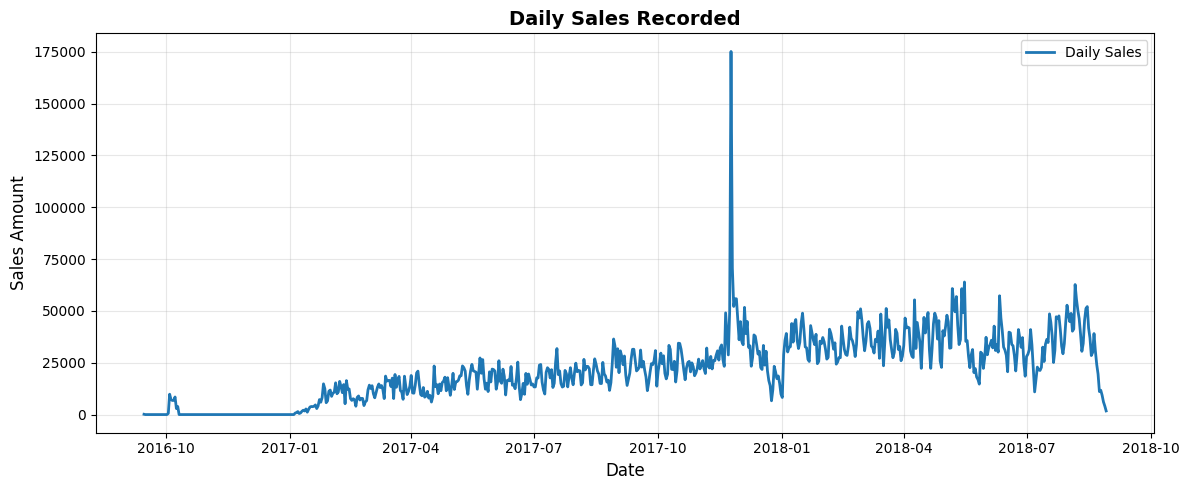

In [221]:
plt.figure(figsize=(12, 5))
plt.plot(sales_forecast_data.index, sales_forecast_data['sales'], label='Daily Sales', linewidth=2)

plt.title('Daily Sales Recorded', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Amount', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [222]:
sales_forecast_data = sales_forecast_data[sales_forecast_data.index >= '2017-02-01']
sales_forecast_data

,sales
order_purchase_timestamp,
2017-02-01,8788.70
2017-02-02,10334.07
2017-02-03,10797.08
2017-02-04,15320.15
2017-02-05,10035.21
...,...
2018-08-25,11737.76
2018-08-26,9333.16
2018-08-27,6111.61


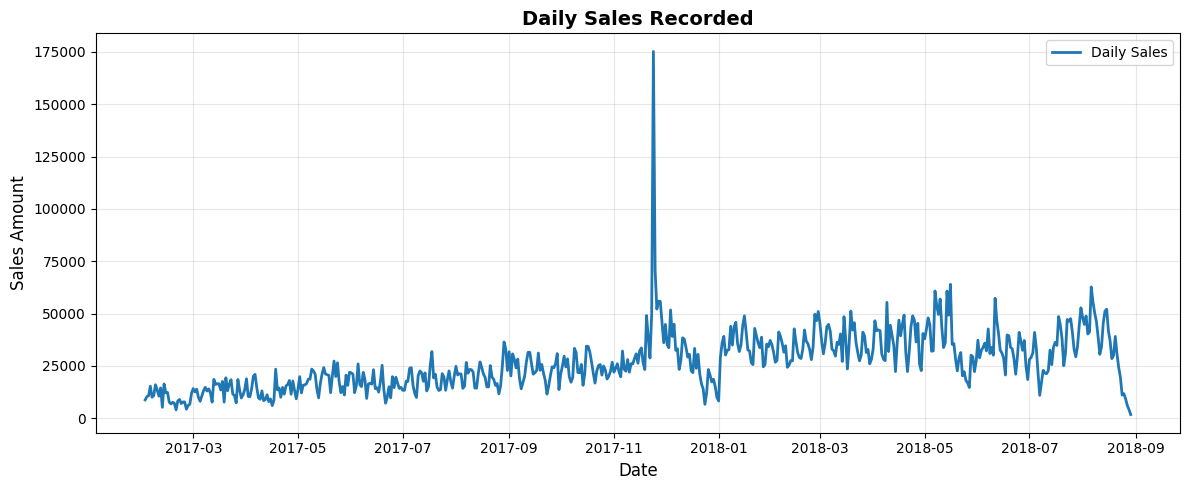

In [223]:
plt.figure(figsize=(12, 5))
plt.plot(sales_forecast_data.index, sales_forecast_data['sales'], label='Daily Sales', linewidth=2)

plt.title('Daily Sales Recorded', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales Amount', fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [224]:
decomposition = seasonal_decompose(sales_forecast_data['sales'], model='additive', period=7)

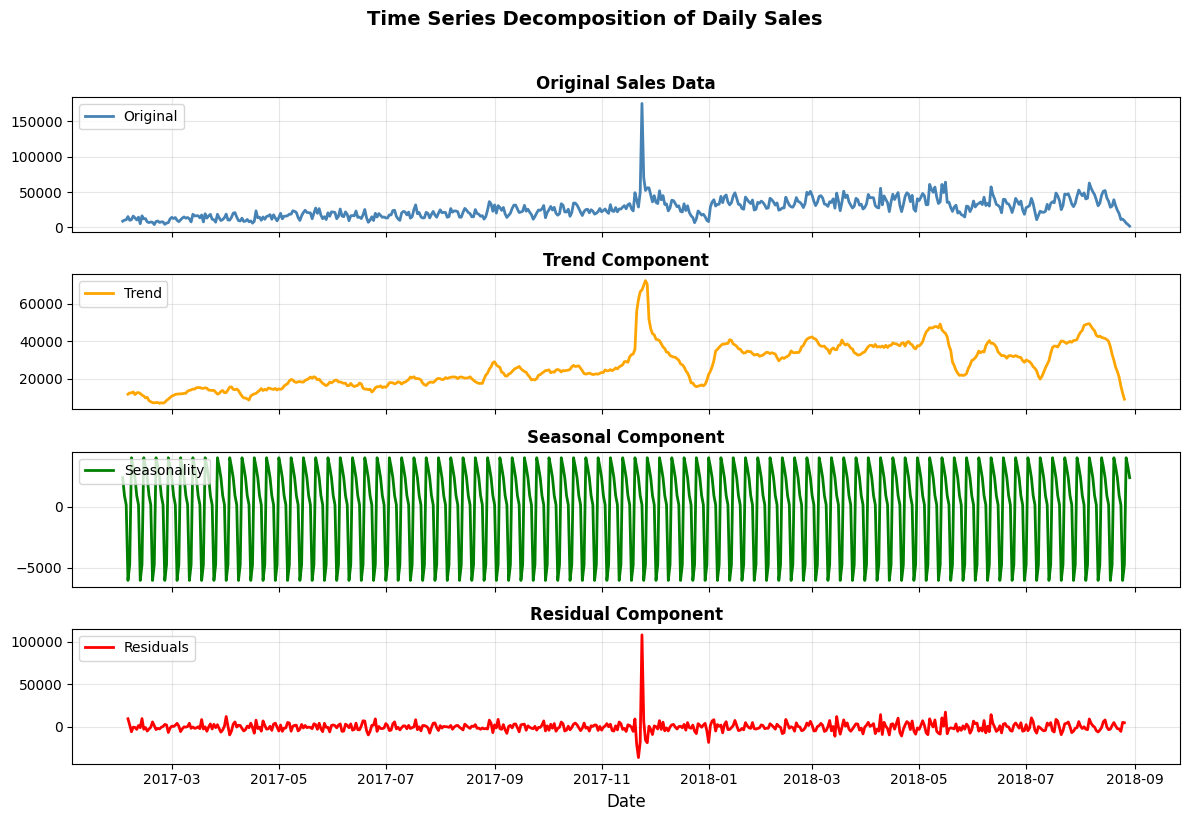

In [225]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# Original series
axes[0].plot(sales_forecast_data['sales'], label='Original', color='steelblue', linewidth=2)
axes[0].set_title('Original Sales Data', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Trend component
axes[1].plot(decomposition.trend, label='Trend', color='orange', linewidth=2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# Seasonal component
axes[2].plot(decomposition.seasonal, label='Seasonality', color='green', linewidth=2)
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

# Residual component
axes[3].plot(decomposition.resid, label='Residuals', color='red', linewidth=2)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].legend(loc='upper left')
axes[3].grid(alpha=0.3)

# Common labels and layout
plt.suptitle('Time Series Decomposition of Daily Sales', fontsize=14, fontweight='bold', y=1.02)
plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

In [226]:
sales_forecast_data.to_csv("Sales Forecasting Data New.csv", index=True)

**Preparing Sales Forecasting Dataset (Amount)**

Filter invalid status

In [227]:
sales_forecast_product_data = order_df[order_df['order_status'] == 'delivered'].drop(['order_status'], axis=1)
sales_forecast_product_data

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...
98638,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
98639,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
98640,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
98641,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [228]:
product_sales_data = order_items_df.merge(sales_forecast_product_data[['order_id', 'order_purchase_timestamp']], on='order_id')
product_sales_data

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51
...,...,...,...,...,...,...,...,...
110168,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,2018-04-23 13:57:06
110169,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,2018-07-14 10:26:46
110170,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,2017-10-23 17:07:56
110171,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,2017-08-14 23:02:59


In [229]:
full_product_sales_data = product_sales_data.merge(product_df, on='product_id', how='left')
full_product_sales_data

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,quantity
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,9
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,1
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,3
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110168,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,2018-04-23 13:57:06,housewares,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,47
110169,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,2018-07-14 10:26:46,computers_accessories,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,2
110170,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,2017-10-23 17:07:56,sports_leisure,43.0,869.0,1.0,967.0,21.0,24.0,19.0,14
110171,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,2017-08-14 23:02:59,computers_accessories,56.0,1306.0,1.0,100.0,20.0,20.0,20.0,11


In [230]:
full_product_sales_data['order_purchase_timestamp'] = pd.to_datetime(full_product_sales_data['order_purchase_timestamp'])
print(f"Total Transactions: {len(full_product_sales_data)}")

Total Transactions: 110173


In [231]:
full_product_sales_data = full_product_sales_data.sort_values('order_purchase_timestamp')
full_product_sales_data = full_product_sales_data.set_index('order_purchase_timestamp')
full_product_sales_data

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,quantity
order_purchase_timestamp,,,,,,,,,,,,,,,,
2016-09-15 12:16:38,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,health_beauty,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,4
2016-09-15 12:16:38,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,health_beauty,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,4
2016-09-15 12:16:38,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,health_beauty,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,4
2016-10-03 09:44:50,3b697a20d9e427646d92567910af6d57,1,3ae08df6bcbfe23586dd431c40bddbb7,522620dcb18a6b31cd7bdf73665113a9,2016-10-21 16:27:20,29.90,15.56,watches_gifts,63.0,1642.0,3.0,300.0,16.0,16.0,16.0,1
2016-10-03 16:56:50,be5bc2f0da14d8071e2d45451ad119d9,1,fd7fd78fd3cbc1b0a6370a7909c0a629,f09b760d23495ac9a7e00d29b769007c,2016-10-21 16:33:46,21.90,17.19,sports_leisure,39.0,518.0,1.0,400.0,16.0,16.0,16.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-29 14:18:23,0b223d92c27432930dfe407c6aea3041,2,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,2018-08-31 14:30:19,209.00,46.48,kitchen_dining_laundry_garden_furniture,44.0,112.0,1.0,13550.0,48.0,49.0,49.0,3
2018-08-29 14:18:23,0b223d92c27432930dfe407c6aea3041,1,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,2018-08-31 14:30:19,209.00,46.48,kitchen_dining_laundry_garden_furniture,44.0,112.0,1.0,13550.0,48.0,49.0,49.0,3
2018-08-29 14:18:28,168626408cb32af0ffaf76711caae1dc,1,bdcf6a834e8faa30dac3886c7a58e92e,2a84855fd20af891be03bc5924d2b453,2018-08-31 14:30:23,45.90,15.39,health_beauty,26.0,394.0,1.0,1614.0,31.0,16.0,28.0,32


In [232]:
full_product_sales_data = full_product_sales_data[full_product_sales_data.index >= '2017-02-01']
full_product_sales_data

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,quantity
order_purchase_timestamp,,,,,,,,,,,,,,,,
2017-02-01 08:42:43,0e659173ebf2a1d39e076be9bd0b2872,1,6f26402132b4c218396901cc4cf2804a,3a52d63a8f9daf5a28f3626d7eb9bd28,2017-02-10 08:42:43,35.00,17.78,sports_leisure,48.0,516.0,3.0,613.0,24.0,15.0,20.0,1
2017-02-01 08:42:45,34605af753e44da907f983de0082faaf,1,991669e10bb13b3502329f768c98c7e6,6b9b80d53ba3676eafe60268a810b5a1,2017-02-08 08:42:45,29.90,17.78,sports_leisure,31.0,987.0,8.0,300.0,18.0,6.0,15.0,1
2017-02-01 08:45:22,7a30c15d4766a1dcd8e9cb869cdb328e,1,25a1c5b2e0ccbf703cb7b69ffebfaf38,56642bcb79900e777d68e91915cb4267,2017-02-05 08:45:22,48.00,22.28,garden_tools,39.0,1507.0,2.0,1100.0,20.0,20.0,20.0,7
2017-02-01 09:08:09,bf79d036f5374ea92a94c50341ada3da,1,2239cf6b4421c4bd57f8a87127800929,7c67e1448b00f6e969d365cea6b010ab,2017-02-10 09:08:09,129.99,46.40,office_furniture,26.0,989.0,1.0,16125.0,81.0,7.0,83.0,7
2017-02-01 09:08:50,9209e9a4ad05cf804c49922051fc44d9,1,25a1c5b2e0ccbf703cb7b69ffebfaf38,56642bcb79900e777d68e91915cb4267,2017-02-05 09:08:50,48.00,22.28,garden_tools,39.0,1507.0,2.0,1100.0,20.0,20.0,20.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-29 14:18:23,0b223d92c27432930dfe407c6aea3041,2,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,2018-08-31 14:30:19,209.00,46.48,kitchen_dining_laundry_garden_furniture,44.0,112.0,1.0,13550.0,48.0,49.0,49.0,3
2018-08-29 14:18:23,0b223d92c27432930dfe407c6aea3041,1,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,2018-08-31 14:30:19,209.00,46.48,kitchen_dining_laundry_garden_furniture,44.0,112.0,1.0,13550.0,48.0,49.0,49.0,3
2018-08-29 14:18:28,168626408cb32af0ffaf76711caae1dc,1,bdcf6a834e8faa30dac3886c7a58e92e,2a84855fd20af891be03bc5924d2b453,2018-08-31 14:30:23,45.90,15.39,health_beauty,26.0,394.0,1.0,1614.0,31.0,16.0,28.0,32


In [233]:
weekly_data = (
    full_product_sales_data.groupby(['product_id', 'product_category_name'])
    .resample('W')
    .agg({
        'order_id': 'count',           # Quantity
        'price': 'mean',               # Price
        'product_weight_g': 'first',   # Weight (will generate NaNs)
        'product_photos_qty': 'first'  # Photos (will generate NaNs)
    })
    .rename(columns={'order_id': 'quantity'})
)

In [234]:
all_weeks = pd.date_range(start='2017-02-05', end='2018-08-29', freq='W')
unique_products = full_product_sales_data[['product_id', 'product_category_name']].drop_duplicates()
index = pd.MultiIndex.from_product(
    [unique_products['product_id'], all_weeks], 
    names=['product_id', 'order_purchase_timestamp']
)
full_grid = pd.DataFrame(index=index).reset_index()
full_grid = full_grid.merge(unique_products, on='product_id', how='left')
full_grid
final_product_sales_data = full_grid.merge(
    weekly_data, 
    on=['product_id', 'product_category_name', 'order_purchase_timestamp'], 
    how='left'
)
final_product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty
0,6f26402132b4c218396901cc4cf2804a,2017-02-05,sports_leisure,1.0,35.0,613.0,3.0
1,6f26402132b4c218396901cc4cf2804a,2017-02-12,sports_leisure,NaN,NaN,NaN,NaN
2,6f26402132b4c218396901cc4cf2804a,2017-02-19,sports_leisure,NaN,NaN,NaN,NaN
3,6f26402132b4c218396901cc4cf2804a,2017-02-26,sports_leisure,NaN,NaN,NaN,NaN
4,6f26402132b4c218396901cc4cf2804a,2017-03-05,sports_leisure,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2609973,c7f27c5bef2338541c772b5776403e6a,2018-07-29,party_supplies,NaN,NaN,NaN,NaN
2609974,c7f27c5bef2338541c772b5776403e6a,2018-08-05,party_supplies,NaN,NaN,NaN,NaN
2609975,c7f27c5bef2338541c772b5776403e6a,2018-08-12,party_supplies,NaN,NaN,NaN,NaN
2609976,c7f27c5bef2338541c772b5776403e6a,2018-08-19,party_supplies,NaN,NaN,NaN,NaN


In [235]:
final_product_sales_data['quantity'] = final_product_sales_data['quantity'].fillna(0) # Sales are 0

product_static_info = product_df[['product_id', 'product_weight_g', 'product_photos_qty']]
cols_to_drop = ['product_weight_g', 'product_photos_qty']
final_product_sales_data = final_product_sales_data.drop(columns=cols_to_drop, errors='ignore')
final_product_sales_data = final_product_sales_data.merge(product_static_info, on='product_id', how='left')

final_product_sales_data = final_product_sales_data.sort_values(['product_id', 'order_purchase_timestamp'])
final_product_sales_data['price'] = (
    final_product_sales_data.groupby('product_id')['price']
    .ffill()
    .bfill()
)
final_product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty
2078290,00066f42aeeb9f3007548bb9d3f33c38,2017-02-05,perfumery,0.0,101.65,300.0,6.0
2078291,00066f42aeeb9f3007548bb9d3f33c38,2017-02-12,perfumery,0.0,101.65,300.0,6.0
2078292,00066f42aeeb9f3007548bb9d3f33c38,2017-02-19,perfumery,0.0,101.65,300.0,6.0
2078293,00066f42aeeb9f3007548bb9d3f33c38,2017-02-26,perfumery,0.0,101.65,300.0,6.0
2078294,00066f42aeeb9f3007548bb9d3f33c38,2017-03-05,perfumery,0.0,101.65,300.0,6.0
...,...,...,...,...,...,...,...
2061147,fffe9eeff12fcbd74a2f2b007dde0c58,2018-07-29,toys,0.0,249.99,3900.0,3.0
2061148,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-05,toys,0.0,249.99,3900.0,3.0
2061149,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-12,toys,0.0,249.99,3900.0,3.0
2061150,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-19,toys,0.0,249.99,3900.0,3.0


In [236]:
print("Remaining Missing Values:")
print(final_product_sales_data.isnull().sum())

Remaining Missing Values:
product_id                  0
order_purchase_timestamp    0
product_category_name       0
quantity                    0
price                       0
product_weight_g            0
product_photos_qty          0
dtype: int64


In [237]:
category_cleanup = {
    'home_appliances_2': 'home_appliances',
    'home_comfort_2': 'home_comfort' 
}
final_product_sales_data['product_category_name'] = final_product_sales_data['product_category_name'].replace(category_cleanup)
final_product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty
2078290,00066f42aeeb9f3007548bb9d3f33c38,2017-02-05,perfumery,0.0,101.65,300.0,6.0
2078291,00066f42aeeb9f3007548bb9d3f33c38,2017-02-12,perfumery,0.0,101.65,300.0,6.0
2078292,00066f42aeeb9f3007548bb9d3f33c38,2017-02-19,perfumery,0.0,101.65,300.0,6.0
2078293,00066f42aeeb9f3007548bb9d3f33c38,2017-02-26,perfumery,0.0,101.65,300.0,6.0
2078294,00066f42aeeb9f3007548bb9d3f33c38,2017-03-05,perfumery,0.0,101.65,300.0,6.0
...,...,...,...,...,...,...,...
2061147,fffe9eeff12fcbd74a2f2b007dde0c58,2018-07-29,toys,0.0,249.99,3900.0,3.0
2061148,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-05,toys,0.0,249.99,3900.0,3.0
2061149,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-12,toys,0.0,249.99,3900.0,3.0
2061150,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-19,toys,0.0,249.99,3900.0,3.0


In [238]:
top_20_categories = (
    final_product_sales_data.groupby('product_category_name')['quantity']
    .sum()
    .nlargest(20)
    .index
)
final_product_sales_data['product_category_name'] = final_product_sales_data['product_category_name'].apply(
    lambda x: x if x in top_20_categories else 'Other'
)

final_product_sales_data

,product_id,order_purchase_timestamp,product_category_name,quantity,price,product_weight_g,product_photos_qty
2078290,00066f42aeeb9f3007548bb9d3f33c38,2017-02-05,perfumery,0.0,101.65,300.0,6.0
2078291,00066f42aeeb9f3007548bb9d3f33c38,2017-02-12,perfumery,0.0,101.65,300.0,6.0
2078292,00066f42aeeb9f3007548bb9d3f33c38,2017-02-19,perfumery,0.0,101.65,300.0,6.0
2078293,00066f42aeeb9f3007548bb9d3f33c38,2017-02-26,perfumery,0.0,101.65,300.0,6.0
2078294,00066f42aeeb9f3007548bb9d3f33c38,2017-03-05,perfumery,0.0,101.65,300.0,6.0
...,...,...,...,...,...,...,...
2061147,fffe9eeff12fcbd74a2f2b007dde0c58,2018-07-29,toys,0.0,249.99,3900.0,3.0
2061148,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-05,toys,0.0,249.99,3900.0,3.0
2061149,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-12,toys,0.0,249.99,3900.0,3.0
2061150,fffe9eeff12fcbd74a2f2b007dde0c58,2018-08-19,toys,0.0,249.99,3900.0,3.0


In [239]:
final_product_sales_data.to_csv("Sales Forecasting Data Product Quantity.csv", index=False)